# 2D $\phi^4$ Hamiltonian Truncation on a Circle.

Builds the truncated Hamiltonian for an interacting massive scalar field in 1+1D on a circle of radius $r$:

$$H_\text{eff} = H_0 + H_4 = H_0 + \int dx \frac{\lambda}{4!} :\phi^4:$$

Code used as part of the construction of work arXiv:2607.XXXXX.

References: arXiv:2507.15941, arXiv:2110.08273.

In [1]:
# Calculation imports.
import math
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as sp_linalg
from scipy.sparse import identity
from collections import Counter

# Plotting Imports.
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
%matplotlib inline

# Data Management.
import csv

## 1. Single-particle energy and mode indexing

Modes are labelled by magnitude $l \ge 0$ (momentum $\pm l/r$) and sign $\sigma = \pm 1$.
States are stored as dictionaries `{...,-l₂:n₂₋,-l₁:n₁₋,l₀:n₀,l₁:n₁₊,l₂:n₂₊,...}`.


In [2]:
def omega(l, mQ, r):
    # State Energy
    return math.sqrt(float(l)*float(l)/(r*r) + mQ*mQ)

def gen_omega_list(lmax, mQ, r):
    # Global variable storing a list of all state energies.
    global omega_list
    omega_list = [omega(abs(l), mQ, r) for l in range(0,lmax+1)]

def get_total_occupation_number(state):
    # Returns occupation number for a given state in dictionary format.
    return sum(state.values())

def convert_state_to_list(state, lmax):
    # Returns state held in dictionary to list.
    return [state.get(i, 0) for i in range(-lmax, lmax+1)]


def get_state_energy(state, mQ, r):
    # Returns state energy for state in dictionary format.
    return sum([nl*omega(l, mQ, r) for l, nl in state.items()])

## 2. Basis generation via the integer partitions

The integer partitions of a particular integer $n_\text{max}$ are essentially the ways of constructing that number from summing smaller integers. Here, $n_\text{max}$ will ultimately be an angular momentum state.

`gen_parts` builds a dictionary with all of the ways to create a number $n_\text{max}$ by summing smaller numbers. This is stored in the global state `PARTITIONS` and will allow us to automatically build states in the **zero-total-momentum** sector (`l_total == 0`).
Elements of the `paritions` dictionary appear as e.g. `{5:[[5],[4,1],[3,2],[3,1,1],[2,1,1,1],[1,1,1,1,1]}`.

`gen_parition_counter` then turns the global dictionary `PARTITIONS` into a global frequency dictionary `PARTITION_COUNTER`. Elements of `PARTITION_COUNTER` appear as, e.g. `{5:[Counter({4:1}),Counter({3:1,1:1}),Counter({2:2},Counter({2:1,1:2}),Counter({1:4})}`. 

`gen_partition_energies` computes a list of energies for each set of coins labelled by `l` in `PARTITIONS`. As positive and negative `l` states have the same energy, this only needs computing once.

In [3]:
def gen_parition_counter(partitions):
    #Turns partitions into a global counting dictionary, which is easier to perform operations on.
    global PARTITION_COUNTER
    PARTITION_COUNTER = {}
    for key in partitions.keys():
        PARTITION_COUNTER[key] = [Counter(reversed(val)) for val in partitions[key]]
        

def gen_parts(n_max):
    global PARTITIONS
    # Creates the PARTITIONS dictionary if it does not already exist.
    if 'PARTITIONS' not in globals():
        PARTITIONS = {}
        PARTITIONS.setdefault(1,[[1]]) 
        
    # If we have already calculated up to n_max, just return the dictionary.
    if n_max in PARTITIONS: return(PARTITIONS)
     

    for i in range(max(PARTITIONS.keys())+1,n_max+1):
        #This step is a little complicated so I'll break it down into the two parts of the sum:
        #   1. The first part adds [1] to the end of every list for the previous element (e.g. 6:[[6],...] -> 7:[...,[6, 1],...])
        #   2. The second part adds 1 to the final element of the previous interation (e.g. 6:[...,[3,2,1],...]->7:[...,[3,2,2],...]) given the following conditions:
        #       a) If the length of the dictionary is 1, just add one (i.e 6:[[6],..] -> 7:[[7],...])
        #       b) If the final two elements of a list are the same, there also exists one where the final two elements differ by two (e.g. 6:[...,[3,3],[4,2],...]).
        #          Without input, this would result in duplicate entries. Therefore, the final two elements must not be equal for this step.

        PARTITIONS[i] = [cns[:-1]+[cns[-1]+1] for cns in PARTITIONS[i-1] if (len(cns)==1 or cns[-2]!=cns[-1])] + list(map(lambda x:x+[1], PARTITIONS[i-1])) 
        
    # Creating a counting dictionary version of this as it is easier to perform operations on.
    gen_parition_counter(PARTITIONS)
    return PARTITIONS


def partition_energies(l,mQ,r):
    #Computes the energies of each possible partition for the state l.
    return [sum(map(lambda c: omega(c, mQ, r), change)) for change in PARTITIONS[l]]
            

In [4]:
#Example of the paritions. 
gen_parts(4)
#Just printing states 3 and 4.
for i in range(3,5):
    print(f'lmax = {i}')
    for part in PARTITIONS[i]:
        print(f'Partition = {part}, Energy = {sum(map(lambda c: omega(c, 1, 1), part))}')

lmax = 3
Partition = [3], Energy = 3.1622776601683795
Partition = [2, 1], Energy = 3.6502815398728847
Partition = [1, 1, 1], Energy = 4.242640687119286
lmax = 4
Partition = [4], Energy = 4.123105625617661
Partition = [2, 2], Energy = 4.47213595499958
Partition = [3, 1], Energy = 4.576491222541475
Partition = [2, 1, 1], Energy = 5.06449510224598
Partition = [1, 1, 1, 1], Energy = 5.656854249492381


## Generating the set of basis states

`gen_basis` builds all occupation-number states with energy ≤ `e_max`, by `l` iterating up to `lmax` and each time merging two `PARTITION_COUNTER`'s together (one with negative angular momentum). Zero momentum states are then added up to `e_max`. This produces all ways to build states with `l_total == 0`.

To note about this particular method:

1. States are stored in dictionary form i.e. `{l:nl,...}` where `l` is the angular momentum and `nl` is the corresponding occupancy number.

2. This particular method also stores a list of states to iterate over with one in a pair of Z2 antisymmetric states about `l=0` is retained. For example `{-3:1,1:3}` would be asymmetric. For larger `e_max` just less than 1/2 of the states are in Z2 antisymmetric pairs, which have almost identical(*) transition amplitudes so this aids in reducing computation time later.

3. States are produced with the ordering such that `l` goes from most negative to most positive for each state in the basis.

(*) The key difference is the positioning of the results in the matrix, which is taken care of by the function `fill_matrix_pairs`.

In [5]:
def gen_basis(lmax, e_max, mQ, r):
    iterSet = set({0}) # Set of states to iterate over when generating the transition matrix.

    #l=0:
    result = [{}] # The empty state.

    for i in range(1, int(math.floor(e_max/mQ)) + 1): # Adding l=0 states up to the maximum possible number allowed before reaching e_max.
        result+=[{0: i}] 
        iterSet.add(i)

    #l>0:
    # ix is the running state index which we set to one above the maximum l=0 occupancy.
    ix = int(math.floor(e_max/mQ))+1
    
    
    for l in range(1,lmax+1):
        gen_parts(l) # All ways of making up to lmax with smaller numbers
        gen_parition_counter(PARTITIONS) # Generates a dictionary version
        partEnergies = partition_energies(l,mQ,r) # Energies for each set of coins.

        # Iterate through positive (ii, ci) and negative (jj, cj) momenta, then merge dictionaries.
        for ii,ci in enumerate(PARTITION_COUNTER[l]):
            for jj,cj in enumerate(PARTITION_COUNTER[l]):
                if jj>=ii: # Only make one copy of each asymmetric state.

                    #Build a temporary energy for the state so we can 
                    # A) figure out if it exceeds e_max.
                    # B) add l=0 states successively up to e_max.
                    e_temp = e_max - partEnergies[ii] - partEnergies[jj]
                    
                    if e_temp > 0: #Fill up l=0 state up to e_max.

                        # Merge positive and negative l states, with total l=0. 
                        negative_cj = {-jjj:cjj for jjj,cjj in reversed(cj.items())} # 'reversed' operation here gives correct l-ordering in the state dictionary. NOTE this is not strictly guaranteed to be maintained.
                        
                        
                        result+=[ negative_cj | ci ]
                       
                        # Add to the iterSet and increase state index.
                        iterSet.add(ix)
                        ix += 1

                        if ii!=jj: 
                            # Merge the Z2 reversed dictionaries.
                            negative_ci = {-iii:cii for iii,cii in reversed(ci.items())}
                            result += [ negative_ci | cj ]
                        
                            # Increase state index but do not add to iterSet.
                            ix += 1



                        # Now adding successively more l=0 states up to total e_max.
                        for i in range(1, int(math.floor(e_temp/mQ)) + 1):

                            # Adding successively more l=0 states up to e_max in the center of the dictionary.
                            result+=[ negative_cj | {0:i} | ci ]
                            
                            iterSet.add(ix)
                            ix += 1
                            
                            if ii!=jj: 
                                # Merge the Z2 reversed dictionaries.
                                result += [ negative_ci | {0:i} | cj ]
                                ix += 1
                            
                        
                
    return (result, iterSet)

## 3. Useful Functions

In [6]:
#Helper function which calculates the maximum angular momentum pairs which can be produced, still below e_max.
def effective_lmax(lmax, e_max, mQ, r):
    if mQ**2 < e_max**2 / 4:
        return int(min(lmax, math.floor(math.sqrt(max(0, r**2*(e_max**2/4 - mQ**2))))))
    return 0

In [7]:
def falling_factorial(x,k):
    # x is the value and k is the number of falling factorial steps to take.
    return math.prod(x - i for i in range(k))

def raising_factorial(x,k):
    # x is the value and k is the number of raising factorial steps to take.
    return math.prod(x + i for i in range(k))

## 4. Transition Matrix

Constructs the matrix for:

 $$H_\text{eff} = H_0 + H_4 = H_0 + \int dx \frac{\lambda}{4!} :\phi^4:$$

as defined in Eq. (2.15).

In [8]:
def basis_even(basis, iterSet):  
    # Collecting only even states, creating a hashable basis to locate the position of a particular state in the basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    
    even_basis = []; even_hashable_states = {tuple({}):0}; even_iterset = set()
    
    basislen = len(basis); runner = 0 # runner to keep track of the basis index.
    

    for ix in iterSet: # Iterate through the iterSet list of the minimum necessary states to compute.
        s = basis[ix] # Grabs the corresponding dictionary representation of the state
            
        if sum(s.values()) % 2 == 0: # Confirm occupancy number is even.
            # If so add to the necessary data structures.
            even_basis += [s] 
            even_hashable_states[tuple(s.items())] = runner
            even_iterset.add(runner)
            # Increase state index by one.
            runner += 1
            
            
            if ix<basislen-1 and ix+1 not in iterSet: # Confirm if state is part of Z2 antisymmetric pair.
                # If so, add that to (hashable) basis. Do not add to the iterset.
                a_s = basis[ix+1]
                even_basis += [a_s]
                even_hashable_states[tuple(a_s.items())] = runner
                # Increase state index by one.
                runner += 1


    return (even_basis, even_hashable_states, even_iterset)

def basis_odd(basis, iterSet):  
    # Collecting only odd states, creating a hashable basis to locate the position of a particular state in the basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    odd_basis = []; odd_hashable_states = {tuple({}):0}; odd_iterset = set()
    
    basislen = len(basis); runner = 0 # runner to keep track of the basis index.
    
    for ix in iterSet: # Iterate through the iterSet list of the minimum necessary states to compute.
        s = basis[ix] # Grabs the corresponding dictionary representation of the state
            
        if sum(s.values()) % 2 != 0: # Confirm occupancy number is odd.
            # If so add to the necessary data structures.
            odd_basis += [s]
            odd_hashable_states[tuple(s.items())] = runner
            odd_iterset.add(runner)
            # Increase state index by one.
            runner += 1

            if ix<basislen-1 and ix+1 not in iterSet: # Confirm if state is part of Z2 antisymmetric pair.
                # If so, add that to (hashable) basis. Do not add to the iterset.
                a_s = basis[ix+1]
                odd_basis += [a_s]
                odd_hashable_states[tuple(a_s.items())] = runner
                # Increase state index by one.
                runner += 1


    return (odd_basis, odd_hashable_states, odd_iterset)


def basis_all(basis, iterSet):  
    # Collecting all states, creating a hashable basis to locate the position of a particular state in the basis.
    # The hashable basis is of the form {tuple representation of state: state index}
    all_basis = []; all_hashable_states = {tuple({}):0}; all_iterset = set()
    
    basislen = len(basis); runner = 0 # runner to keep track of the basis index.
    
    for ix in iterSet:
        # Grabs the corresponding dictionary representation of the state
        s = basis[ix]
        
        # Add state to the necessary data structures.
        all_basis += [s]
        all_hashable_states[tuple(s.items())] = runner
        all_iterset.add(runner)
        # Increase state index by one.
        runner += 1

        if ix<basislen-1 and ix+1 not in iterSet: # Confirm if state is part of Z2 antisymmetric pair.
            # If so, add that to (hashable) basis. Do not add to the iterset.
            a_s = basis[ix+1]
            all_basis += [a_s]
            all_hashable_states[tuple(a_s.items())] = runner
            # Increase state index by one.
            runner += 1

    return (all_basis, all_hashable_states, all_iterset)

In [9]:
def fill_matrix_pairs(ix, iy, res, ixPaired, iyAbsPaired, iyPresPaired):   
    # A function to fill Z2 antisymmetric pairs into the transition matrix consistently.
    #
    # iy and ix are the results from transition_matrix_phi2 and transition_matrix_phi4's operations and:
    #
    #   ixPaired: Bool, if the ix is part of a Z2 symmetric pair. Checked with `ix<matrixDim-1 and ix+1 not in iterSet`
    #   iyAbsPaired : Bool, the iy is the absent of the pair from iterSet. Checked with `iy not in iterSet`
    #   iyPresPaired : Bool, the iy is the present of the pair from iterSet. Checked with `iy+1 not in iterSet and iy+1<matrixDim`
    #   (If both are False, iy is not part of a Z2 symmetric pair. Note both cannot be simultaneously Tru.e)
    #
    
    if ixPaired and iyAbsPaired: # ix and iy both in a pair, but iy not the iterated of the pair.
        return ([res, res, res, res], [ix, iy, ix+1, iy-1], [iy, ix, iy-1, ix+1])
            
    elif ixPaired and iyPresPaired: # ix and iy both in a pair, and both the iterated pair.
        return ([res, res, res, res], [ix, iy, ix+1, iy+1], [iy, ix, iy+1, ix+1])

    elif ixPaired: # Just ix in a pair.
        return ([res, res, res, res], [ix, iy, ix+1, iy], [iy, ix, iy, ix+1])
        
    elif iyPresPaired:  # Just iy in a pair.
        return ([res, res, res, res], [ix, iy, ix, iy+1], [iy, ix, iy+1, ix])
        
    else: # No pairs.
        return ([res, res], [ix, iy], [iy, ix])
        
        


def transition_matrix_phi4(mQ, r, cphi4, lmaxeff, basis_dict, hashable_basis, iterSet):
    # NOTE:
    # 1. States in basis_dict and hashable_basis MUST be ordered from most negative l to most positive l.
    # 2. The hashable_basis has the correct indices for the full matrix. 
    # 3. This version of the code only computes transition amplitudes for ONE of each Z2 antisymmetric pair. Pairs must be consistently, manually added to index+1. The next state will have index+2.
    # 4. Operations from state |initial> to |final> here always REDUCE energy. The 'transpose' corresponds to INCREASING energy which is performed manually and added to the transition matrix. 


    # --- To store the results. ---
    # Note for the following operations, multiple reductions/additions will likely occur to the same state. coo_matrix then sums all entries in the same location.
    H_eff = []; cols = []; rows = []
    
    # Compute the size of the full matrix.
    matrixDim = len(hashable_basis)
    
    # Now iterate over the reduced set of states.
    for ix in iterSet:
        # Grab the state with index ix.
        state = basis_dict[ix]
        
        # -------------------------------
        # ------- Pre Computation -------
        # -------------------------------
        # Pre-Computing some Properties for speed later.
        ixPaired=False
        if ix<matrixDim-1 and ix+1 not in iterSet: # If the next term in the sequence is skipped, this is an asymmetric pair.
            ixPaired=True

        # -------------------------------
        #  Adding To The Diagonal (H_0) -
        # -------------------------------

        # Add energy to the diagonal:
        if ixPaired:
            # If the state is Z2 antisymmetric, buff H_eff with an additional entry on the next diagonal.
            res = get_state_energy(state, mQ, r)
            H_eff.extend([res,res]); rows.extend([ix,ix+1]); cols.extend([ix,ix+1])
        else:
            # Otherwise just add to the current diagonal.
            res = get_state_energy(state, mQ, r)
            H_eff.extend([res]); rows.extend([ix]); cols.extend([ix])
            

        # -------------------------------
        # ---- Adding H_4 Operations ----
        # -------------------------------

        # All operations contain at least two annihilation operators.

        # --- Annihilation of l ---
        for l,nl in state.items():
            if nl == 0: continue # Confirming there is an occupier in the state.
            
            # Computation of base factor for removing momentum l.
            l_base = math.sqrt(nl/omega_list[abs(l)])

            # Modify current state.
            state[l] -= 1
            # NOTE if occupancy drops to zero, do not remove from dictionary. It helps to preserve ordering.

            # --- Annihilation of ll ---
            for ll,nll in state.items():
                if nll == 0: continue # Confirming there is an occupier in the state.
                
                # --- --- --- --- --- --- --- --- --- --- --- --- --
                # --- --- --- --- 0. Preparations --- --- --- --- --
                # --- --- --- --- --- --- --- --- --- --- --- --- --
                
                if ll>l: break # This clause automatically terminates anything which would double-count.
                if abs(l+ll)>lmaxeff:continue # Avoid encountering unreachable states with momentum above lmaxeff
                
                # Computation of the base factor for removing momenta l and ll.
                ll_base = l_base * math.sqrt(nll/omega_list[abs(ll)])
                # Fix factor if l and ll identical.
                if ll == l: ll_base *= (1/2)
                
                # Modify current state again.
                state[ll] -= 1


                # --- --- --- --- --- --- --- --- --- --- --- --- --
                # -- 1. Remove two states and add two states back --
                # ---- Corresponds to the fifth row of Table 2. ----
                # --- --- --- --- --- --- --- --- --- --- --- --- --
                

                # --- Adding and removing the same two states (i.e. l and ll) ---
                # Transition Amplitude
                res = cphi4 * ll_base ** 2
                
                # Apply the Diagonal with the \phi^4 operator.
                if ixPaired:
                    # If the state is Z2 antisymmetric, buff H_eff with an additional entry on the next diagonal.
                    H_eff.extend([res, res]); rows.extend([ix,ix+1]); cols.extend([ix,ix+1])
                else:
                    # Otherwise just add to the current diagonal.
                    H_eff.extend([res]); rows.extend([ix]); cols.extend([ix])

                # --- --- --- --- --- --- --- --- --- --- --- --- --
                # - 2. Remove two and add back two different states-
                # ---- Corresponds to the fourth row of Table 2. ---
                # --- --- --- --- --- --- --- --- --- --- --- --- --

                if abs(ll-l)>1: # Note this again avoids double-counting. 
                    # I.e. if l=-ll, l_total removed is zero. Either the add_l and add_ll are equal (in which case we recover the case above), or they differ (in which case another iteration of the loop will catch this condition).
                    

                    # We iterate through each addition without double-counting by (recall we have set l>ll):
                    #  A) reducing the added momenta from l by one, 
                    #  B) increasing the added momenta from ll by one. 
                    # This ensures the total added angular momentum is still identical to before, and we do not double-count states.

                    # This clause calculates the maximum number of times we perform the procedure before we double-count.
                    iteration = math.ceil((abs(ll-l)+1)/2) if -ll!=l else abs(ll)+1 
                    
                    
                    for i in reversed(range(1, iteration)):
                        # As mentioned, adding to ll and removing from l sequentially.
                        stA = ll+i; stB = l-i
                        
                        # Updating the current state with the added operations.
                        # --- Creation of stA ---
                        if stA not in state.keys(): state[stA] = 1
                        else: state[stA] += 1
                        # --- Creation of stB ---
                        if stB not in state.keys(): state[stB] = 1
                        else: state[stB] += 1
                        
                        # Re-sort the target state into the correct ordering, and convert to tuple to use the hashtable.
                        final_state = tuple(sorted([(a,b) for a,b in state.items() if b!= 0])) 
                        
                        
                        nstA = state[stA]; estA = omega_list[abs(stA)]
                        # Calculating the transition matrix element for adding stA and stB back on.
                        if stA == stB:
                            res = (cphi4) * ll_base * math.sqrt((nstA-1)*(nstA)) / (2 * estA)
                        else:
                            nstB = state[stB]; estB = omega_list[abs(stB)]
                            res = (cphi4) * ll_base * math.sqrt((nstA)*(nstB) / (estA * estB))
                        
                        
                        # Look up the new target state in the hashable_basis table to find the index of the new state.
                        iy = hashable_basis.get(final_state)

                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose).
                        _H_eff, _cols, _rows = fill_matrix_pairs(ix, iy, res, ixPaired, iy not in iterSet, iy+1 not in iterSet and iy+1<matrixDim)
                        H_eff.extend(_H_eff); cols.extend(_cols); rows.extend(_rows)
                    

                        # Return state back to it's previous form.
                        state[stA] -= 1
                        if state[stA] == 0 and stA not in {l,ll}:
                            del state[stA]
                        state[stB] -= 1
                        if state[stB] == 0 and stB not in {l,ll}:
                            del state[stB]


                # --- Annihilation of lll ---
                for lll,nlll in state.items():
                    if nlll == 0: continue # Confirming we can do this.
                    if lll>ll: break # Again this clause automatically terminates anything which would double-count.
                         
                    # Modify current state again.
                    state[lll]-=1
                    
                    # To maintain zero total angular momentum, we will add the state add_l and attempt to remove the state sub_l.
                    add_l = (l+ll+lll)
                    sub_l = -(l+ll+lll)
                    
                    # Computation of the base factor for removing momenta l, ll and lll. 
                    # NOTE This is also scaled by 1/sqrt(energy) of the add_l/sub_l state, as it is the same for both following operations.
                    lll_base = ll_base * math.sqrt(nlll/(omega_list[abs(add_l)] * omega_list[abs(lll)]))
                    
                    # Fixing the symmetry factor for repeated operations.
                    if lll == ll == l: lll_base *= (1/3)
                    elif lll == ll or lll == l: lll_base *= (1/2)
                    

                    # --- --- --- --- --- --- --- --- --- --- --- --- --
                    # -- 3. Remove three states and add one state back -
                    # ---- Corresponds to the second row of Table 2. ---
                    # --- --- --- --- --- --- --- --- --- --- --- --- --
                    
                    # --- Creation of add_l ---
                    if add_l in state.keys(): # If this particular angular momentum exists in the dictionary we just add it on.
                        state[add_l]+=1 
                        # Tuple representation to use the hashable_basis. Remove non-occupied momenta.
                        final_state = tuple((a,b) for a,b in state.items() if b!= 0)
                    else: # If this particular angular momentum does not exist in the dictionary we add it and must now re-sort the dictionary to use the hashable basis table.
                        state[add_l]=1
                        # Tuple representation to use the hashable_basis. Remove non-occupied momenta and sort correctly.
                        final_state = tuple(sorted([(a,b) for a,b in state.items() if b!= 0]))
                    
                    # Calculation of the transition matrix entry.
                    res = (cphi4) * math.sqrt(state[add_l]) * lll_base
                    
                    # Look up the new target state in the hashable_basis table to find the index of the new state.
                    iy = hashable_basis.get(final_state)
                    
                    # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose), as well as Z2 antisymmetric pairs to the correct location.
                    _H_eff, _cols, _rows = fill_matrix_pairs(ix, iy, res, ixPaired, iy not in iterSet, iy+1 not in iterSet and iy+1<matrixDim)
                    H_eff.extend(_H_eff); cols.extend(_cols); rows.extend(_rows)
                    
                    
                    # Return current state back to it's original form.
                    state[add_l] -= 1
                    if state[add_l] == 0 and add_l not in {l, ll, lll}:
                        del state[add_l]


                    # --- --- --- --- --- --- --- --- --- --- --- --- --
                    # --- --- ---- 4. Remove four states --- --- --- ---
                    # --- - Corresponds to the first row of Table 2. ---
                    # --- --- --- --- --- --- --- --- --- --- --- --- --

                    # --- Annihilation of sub_l ---
                    if sub_l<=lll and sub_l in state.keys() and state[sub_l] != 0:  # This allows us to avoid double-counting, and confirms there is an occupant for us to remove.

                        # Fixing the symmetry factor for repeated operations.
                        if sub_l == lll == ll == l: lll_base *= (1/4)
                        elif sub_l == lll == ll or sub_l == lll == ll or sub_l == ll == l: lll_base *= (1/3)
                        elif sub_l == lll or sub_l == ll or sub_l == l: lll_base *= (1/2)

                        # Calculation of the transition matrix entry.
                        res = (cphi4) * lll_base * math.sqrt(state[sub_l])
                        
                        # Modify current state again.
                        state[sub_l]-=1
                                
                        # Tuple representation to use the hashable_basis. Remove non-occupied momenta.
                        final_state = tuple((a,b) for a,b in state.items() if b!= 0)
                        # Look up the new target state in the hashable_basis table to find the index of the new state.
                        iy = hashable_basis.get(final_state)
                        

                        # Adds to H_eff both the transition matrix element for removing and adding (basically a transpose), as well as Z2 antisymmetric pairs to the correct location.
                        _H_eff, _cols, _rows = fill_matrix_pairs(ix, iy, res, ixPaired, iy not in iterSet, iy+1 not in iterSet and iy+1<matrixDim)
                        H_eff.extend(_H_eff); cols.extend(_cols); rows.extend(_rows)
                                

                        # Return current state back to it's original form.
                        state[sub_l] += 1
                    
                    # Return current state back to it's original form.
                    state[lll] += 1

                # Return current state back to it's original form.
                state[ll] += 1


            # Return current state back to it's original form.
            state[l] += 1


    # Convert to sparse matrix format. Note there are some diagonal entries in the same location, which is summed by coo_matrix. These are not double-counted states, but contributions from different operations which are supposed to sum.
    H_eff = np.array(H_eff); rows = np.array(rows); cols = np.array(cols)
    return sp.coo_matrix((H_eff,(rows, cols)), shape=(matrixDim,matrixDim))

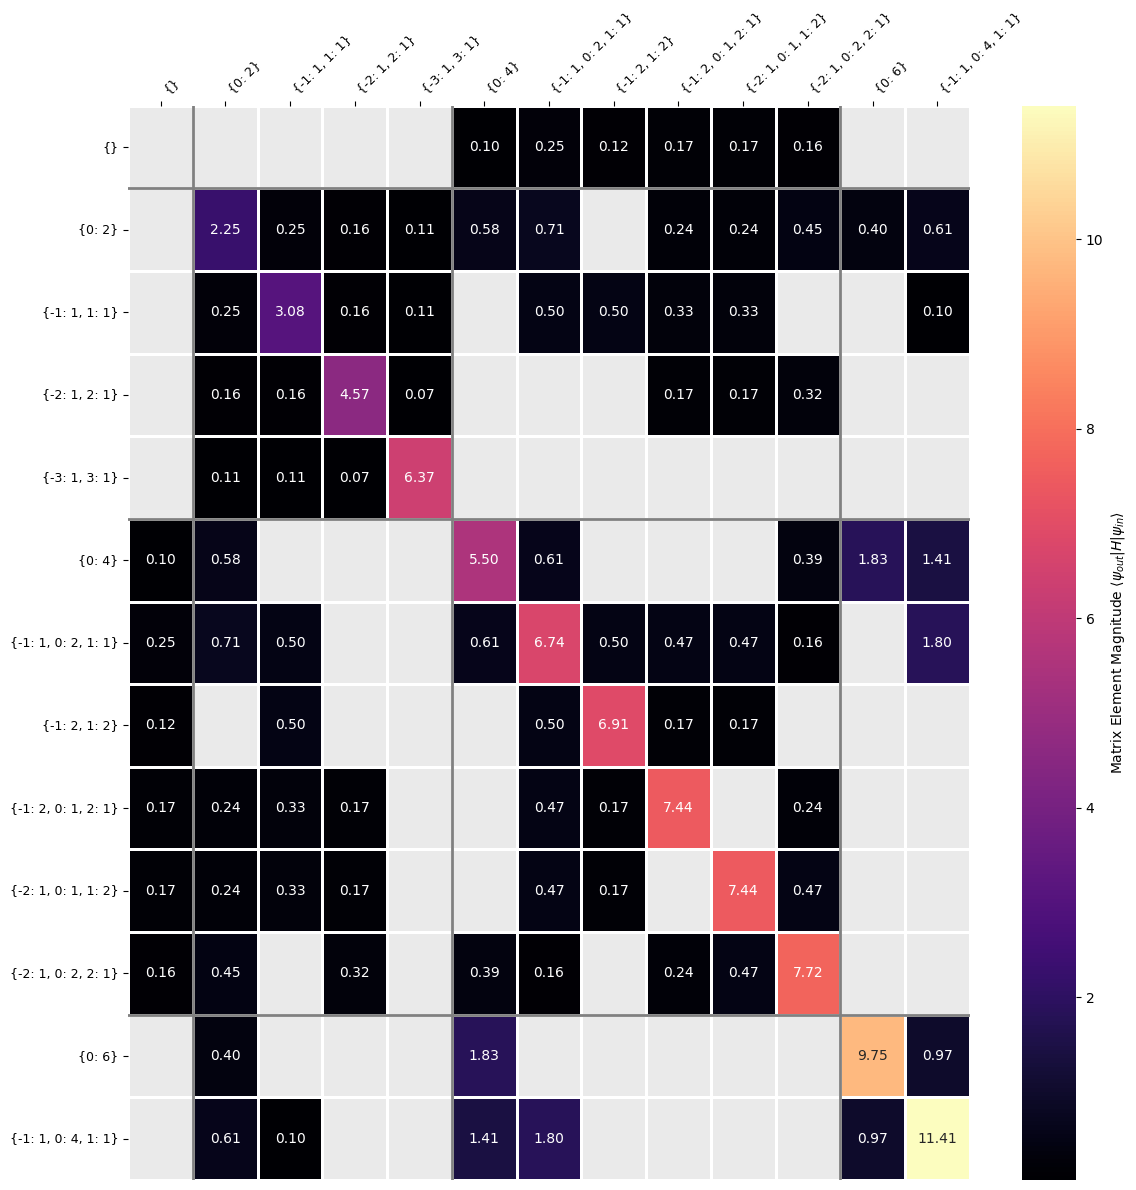

In [22]:
# ---------------------------------
# ---- Prepatation and Inputs -----
# ---------------------------------

# --- Hamiltonian Parameters for Test ---
lmbda = 4*np.pi; mQ = 1.; r = 1.; e_max=7; lmaxeff = effective_lmax(e_max,e_max,mQ,r)
# Compute prefactor
cphi4 = lmbda*(1/(8*math.pi))*(1/r)


# ---------------------------------
# -- Basis and Matrix Generation --
# ---------------------------------

# --- Generate the Basis ---
dict_basis, hashable_basis, iterSet = basis_even(*gen_basis(lmaxeff,e_max,mQ,r)) #Select Even Basis States Only.
# Generate useful lists of energies.
gen_omega_list(lmaxeff, mQ, r)

# --- Run the transition matrix element calculation in phi^4 ---
H_eff_coo=transition_matrix_phi4(mQ, r, cphi4, lmaxeff, dict_basis, hashable_basis, iterSet)

# ---------------------------------
# ------- Plot Preparation --------
# ---------------------------------

full_basis=dict_basis

# 1. Compute properties.
occupation_numbers = np.array([get_total_occupation_number(state) for state in full_basis]) # State Occupation Number for each in basis.
full_state_energies = np.array([get_state_energy(state, mQ, r) for state in full_basis]) ## State Energies for each in basis.


# 2. Sort the basis using lexsort, primarily by occupation number, secondly by energy.
double_sorted_indices = np.lexsort((full_state_energies, occupation_numbers)) 
sorted_full_basis = [full_basis[i] for i in double_sorted_indices]
H_sorted = H_eff_coo.toarray()[double_sorted_indices, :][:, double_sorted_indices]


# 3. Identify unique occupation values and their starting indices
# (Using the sorted array guarantees these indices mark the boundaries)
unique_occ, boundaries_vec = np.unique(occupation_numbers[double_sorted_indices], return_index=True)

# 4. Map the boundaries to a dictionary
boundaries = dict(zip(unique_occ, boundaries_vec))


# --- --- Plot --- ---

# --- State labels ---
verbose_labels = []
for state in sorted_full_basis:
#for state in full_basis:
    verbose_labels.append("{"+", ".join(f"{key}: {value}" for key, value in sorted(state.items()) if value !=0)+"}") # Such that they 'look' like a dictionary of states on the plot.

# --- Boundaries between occupation numbers for the plot ---
state_vecs = np.array([convert_state_to_list(state, lmaxeff) for state in sorted_full_basis])
boundaries = np.where(np.diff(np.sort(np.sum(state_vecs, axis=1))))[0] # List of places where state occupation number changes.
boundaries[0] = 0 # Fixing the zero entry.

# --- Plotting the Heatmap Matrix ---
plt.figure(figsize=(12, 12))

zero_mask = (H_sorted == 0.0) # So that we don't have an overcrowded plot.
ax = sns.heatmap(
    H_sorted, 
    annot=True, 
    fmt=".2f", 
    cmap="magma", 
    linewidths=0.8,
    xticklabels=verbose_labels, 
    yticklabels=verbose_labels,
    mask=zero_mask,
    cbar_kws={'label': 'Matrix Element Magnitude $\\langle \\psi_{out} | H | \\psi_{in} \\rangle$'}
)


# Drawing separation dividers between states of differing occupation number.
for b in boundaries:
    ax.axvline(x=b+1, linewidth=2, color="grey")
    ax.axhline(y=b+1, linewidth=2, color="grey")


ax.xaxis.tick_top() # Layout of x-axis.
ax.xaxis.set_label_position('top')
ax.set_facecolor('#eaeaea') # Soft gray for zero elements
plt.xticks(rotation=45, ha='left', fontsize=9)
plt.yticks(rotation=0, fontsize=9)

plt.tight_layout()
plt.show()


### Timing Code to Compare with https://arxiv.org/abs/2110.08273

E_max: 10
 reduced basis length = 35 and number of asymmetric states = 11
 total basis length = 46
539 μs ± 23.1 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 11
 reduced basis length = 53 and number of asymmetric states = 20
 total basis length = 73
945 μs ± 26.2 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 12
 reduced basis length = 73 and number of asymmetric states = 32
 total basis length = 105
1.54 ms ± 12.5 μs per loop (mean ± std. dev. of 4 runs, 1,000 loops each)
E_max: 13
 reduced basis length = 108 and number of asymmetric states = 54
 total basis length = 162
2.61 ms ± 27.3 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 14
 reduced basis length = 151 and number of asymmetric states = 85
 total basis length = 236
4.23 ms ± 21.3 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
E_max: 15
 reduced basis length = 219 and number of asymmetric states = 133
 total basis length = 352
7.54 ms ± 507 μs per loop (mean ± 

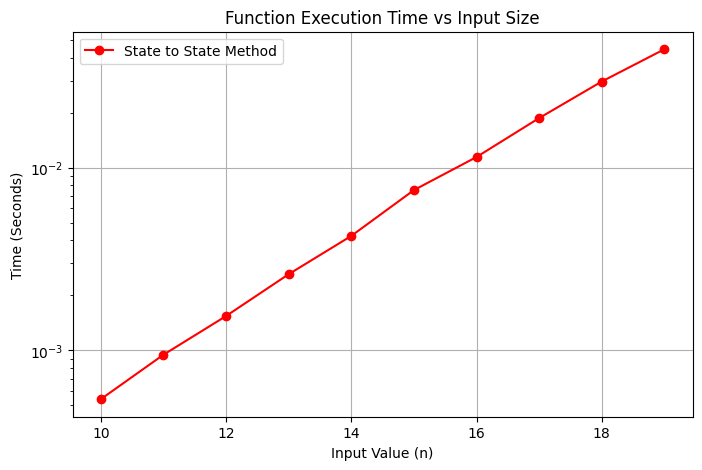

In [11]:
# ---------------------------------
# ---- Prepatation and Inputs -----
# ---------------------------------

# Preparing the parameters for the timing run, and lists for results.
lmbd = 4*np.pi; mQ = 1.; r = 1. # Hamiltonian parameters.
emax_list = range(10,40) #EMax range.

# Compute prefactor
cphi4 = lmbda*(1/(8*math.pi))*(1/r)

execution_times = []; basis_lengths = []

# ---------------------------------
# --- Running the data creation ---
# ---------------------------------


# 1. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    dict_basis, hashable_basis, iterSet  = basis_even(*gen_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.
    print(f' reduced basis length = {len(iterSet)} and number of asymmetric states = {len(dict_basis)-len(iterSet)}')
    print(f' total basis length = {len(dict_basis)}')

    # Timing: 
    duration = %timeit -o -r4 transition_matrix_phi4(mQ, r, cphi4, lmaxeff, dict_basis, hashable_basis, iterSet)
    # Add results to relevant lists.
    execution_times.append(duration.average)
    basis_lengths.append(len(dict_basis))


# 2. Export results to a CSV file
csv_filename = "phi4_statetostate_results.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    writer.writerow(f"mQ = {mQ}, lambda = {lmbd}, r = {r}") # To keep track of HT parameters.
    writer.writerow("EMax List")  # Writes emax list onto file header.
    writer.writerow(emax_list) # To keep track of the relevant emax's used.
    writer.writerow(["Input Value", "Execution Time (Seconds)"])  # Headers
    writer.writerows(zip(emax_list,execution_times))

# 3. Plot the results
plt.figure(figsize=(8, 5))
plt.yscale('log')
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='r', label="State to State Method")
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.legend()
plt.grid(True)
plt.show()

## 5. Diagonalisation

In [12]:
# Default code for which to find the lowest k eigenvalues for a sparse matrix. This is used for timing comparison against basis construction.

def compute_eigenvalues(H, k):
    """Return the k lowest eigenvalues of sparse symmetric H."""
    n = H.shape[0]
    k = min(k, n)
    if k > n - 2:
        return sorted(np.linalg.eigvalsh(H.toarray()))[:k]
    # Shift by the matrix norm so eigs(..., which='LM') finds the most-negative eigenvalues of H
    norm = sp_linalg.norm(H)
    eigs = sp_linalg.eigs(H - norm*identity(n), k, which='LM')[0]
    return sorted((eigs.real + norm).tolist())

E_max: 10
1.98 ms ± 23.3 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
[-0.038690083343425385, 1.9499759036090722, 2.893704722704797, 4.447714471509286, 4.493350053007077]
E_max: 11
2.72 ms ± 50.7 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
[-0.04119356407309738, 1.937934669917496, 2.8814027674466587, 4.413969746027817, 4.478612725589528]
E_max: 12
2.93 ms ± 85.2 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
[-0.04463211534664424, 1.9278057107684106, 2.870695976368438, 4.397171376832887, 4.470873725743843]
E_max: 13
4.17 ms ± 384 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
[-0.04684742104672068, 1.9208545461212054, 2.863240114681645, 4.370593410118033, 4.461273700150599]
E_max: 14
4.85 ms ± 184 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
[-0.0490776357817424, 1.9137139001192338, 2.854999768704346, 4.357547300693568, 4.45441955421532]
E_max: 15
5.63 ms ± 77.1 μs per loop (mean ± std. dev. of 4 runs, 100 loops each)
[-0.0512484

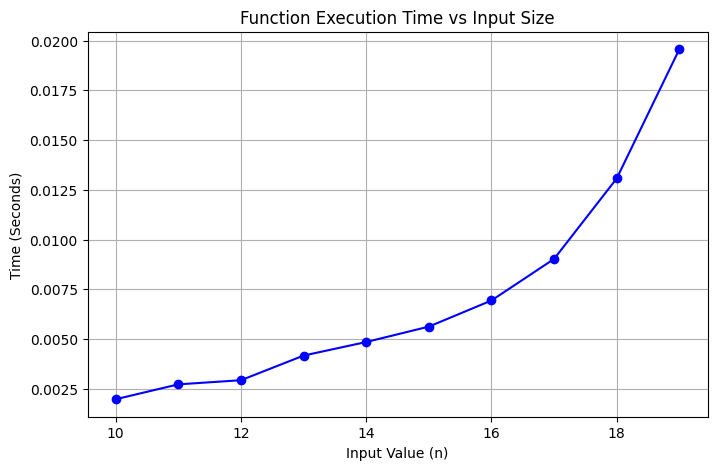

In [13]:
# ---------------------------------
# ---- Prepatation and Inputs -----
# ---------------------------------

# Hamiltonian parameters.
mQ = 1.; r = 1.; lmbda=4*np.pi 
# Test list.
emax_list = range(10,40)

# Result lists
execution_times = []; basis_lengths = []

# Compute prefactor
cphi4 = lmbda*(1/(8*math.pi))*(1/r)


# ---------------------------------
# --- Running the data creation ---
# ---------------------------------

for e_max in emax_list:
    print(f"E_max: {e_max}")
    
   # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = effective_lmax(e_max,e_max,mQ,r)
    # Generate the basis and energy list.
    dict_basis, hashable_basis, iterSet  = basis_even(*gen_basis(lmaxeff,e_max,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)
    
    H = transition_matrix_phi4(mQ, r, cphi4, lmaxeff, dict_basis, hashable_basis, iterSet)
    
    # --- Time the to calculate the first 5 eigenvalues --- 
    duration = %timeit -o -r4 compute_eigenvalues(H, 5)
    
    print(compute_eigenvalues(H, 5))

    # Store results.
    execution_times.append(duration.average)
    basis_lengths.append(len(dict_basis))
    

# 3. Export results to a CSV file
csv_filename = "phi4_benchmark_diagonalisation.csv"
with open(csv_filename, mode="w", newline="") as file:
    writer = csv.writer(file)
    # Writes Hamiltonian parameters for check.
    writer.writerow(f"mQ = {mQ}, lambda = {lmbda}, r = {r}")
    # Writes emax list as header.
    writer.writerow("EMax List")  
    # Writes emax list.
    writer.writerow(emax_list)
    # Finally writes result header and results.
    writer.writerow(["Input Value", "Execution Time (Seconds)"]) 
    writer.writerows(zip(emax_list,execution_times))


# 4. Plot the results
plt.figure(figsize=(8, 5))
plt.plot(emax_list, execution_times, marker='o', linestyle='-', color='b')
plt.title('Function Execution Time vs Input Size')
plt.xlabel('Input Value (n)')
plt.ylabel('Time (Seconds)')
plt.grid(True)
plt.show()

## 6. Sparsity Scaling Plots

In [14]:
# 1. Preparing the parameters for the timing run, and lists for results.
mQ = 1.; r = 1.; lmbda = 4*np.pi # Hamiltonian parameters.
emax_list = range(10,40) #EMax range.

# Compute prefactor
cphi4 = lmbda*(1/(8*math.pi))*(1/r)
# Prepare results lists
sparsity_frac = []; basis_lengths = []


# 2. Run through emax list and time creation.
for emax in emax_list:
    print(f"E_max: {emax}")

    # Timing the transition matrix creation.
    # Compute the effective lmax.
    lmaxeff = effective_lmax(emax,emax,mQ,r)
    # Generate the basis and energy list.
    dict_basis, hashable_basis, iterList  = basis_all(*gen_basis(lmaxeff,emax,mQ,r))
    gen_omega_list(lmaxeff, mQ, r)

    # Just to keep track of the basis length and how much we've saved by only going through one set of an anti-symmetric pair.

    # Produces the transition matrix
    H_total = transition_matrix_phi4(mQ, r, cphi4, lmaxeff, dict_basis, hashable_basis, iterList)
    # Add results to relevant lists.
    sparsity_frac.append(H_total.nnz/len(dict_basis)**2)
    basis_lengths.append(len(dict_basis))
    
    print(f' sparsity fraction = {H_total.nnz/len(dict_basis)**2}')
    print(f' basis length = {len(dict_basis)}')


E_max: 10
 sparsity fraction = 0.2303875236294896
 basis length = 92
E_max: 11
 sparsity fraction = 0.17846184799557366
 basis length = 141
E_max: 12
 sparsity fraction = 0.14408163265306123
 basis length = 210
E_max: 13
 sparsity fraction = 0.11053496514203473
 basis length = 313
E_max: 14
 sparsity fraction = 0.08388121849660311
 basis length = 468
E_max: 15
 sparsity fraction = 0.06390278528934559
 basis length = 688
E_max: 16
 sparsity fraction = 0.049442208269744034
 basis length = 997
E_max: 17
 sparsity fraction = 0.03807768582368743
 basis length = 1431
E_max: 18
 sparsity fraction = 0.02914743573564783
 basis length = 2059
E_max: 19
 sparsity fraction = 0.022429777295410278
 basis length = 2926
E_max: 20
 sparsity fraction = 0.017312089412789923
 basis length = 4135
E_max: 21
 sparsity fraction = 0.01341578983473317
 basis length = 5779
E_max: 22
 sparsity fraction = 0.010350792814429959
 basis length = 8080
E_max: 23
 sparsity fraction = 0.008061576133659496
 basis length = 1

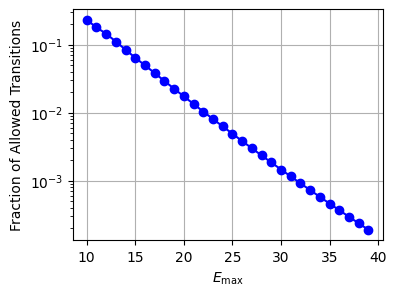

In [15]:
# 4. Plot the results
plt.figure(figsize=(4, 3))
plt.yscale('log')
plt.plot(emax_list, sparsity_frac, marker='o', linestyle='-', color='b')
plt.xlabel(rf'$E_\text{{max}}$')
plt.ylabel('Fraction of Allowed Transitions')
plt.grid(True)
plt.savefig('phi4_sparsity_emax.pdf',format='pdf', bbox_inches="tight", pad_inches=0.1)

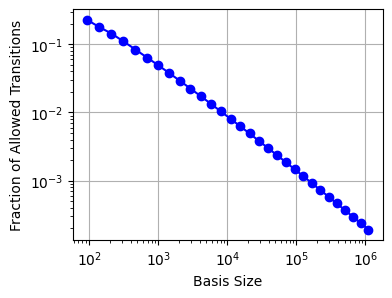

In [16]:
# 5. Plot the results
plt.figure(figsize=(4, 3))
plt.yscale('log')
plt.xscale('log')
plt.plot(basis_lengths, sparsity_frac, marker='o', linestyle='-', color='b')
plt.xlabel(rf'Basis Size')
plt.ylabel('Fraction of Allowed Transitions')
plt.grid(True)
plt.savefig('phi4_sparsity_basislen.pdf',format='pdf', bbox_inches="tight", pad_inches=0.1)

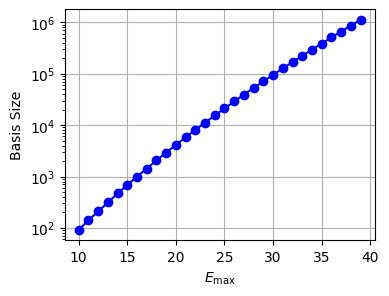

In [17]:
# 6. Plot the results
plt.figure(figsize=(4, 3))
plt.yscale('log')
plt.plot(emax_list, basis_lengths, marker='o', linestyle='-', color='b')
plt.ylabel(rf'Basis Size')
plt.xlabel(rf'$E_\text{{max}}$')
plt.grid(True)
plt.savefig('sparsity_basislen.pdf',format='pdf', bbox_inches="tight", pad_inches=0.1)